# 第 4 章 OpenCV 影像變形處理

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

### 4-1-1 程式範例：影像剪裁

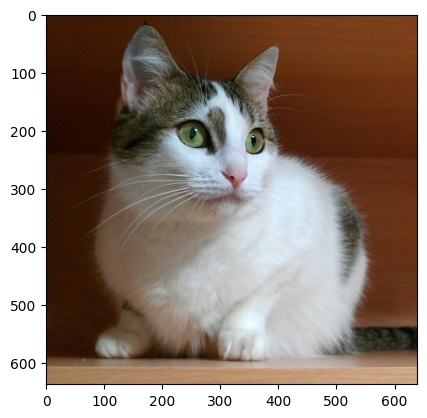

In [2]:
file_name = "sample/cat.jpg" # 影像路徑
img = cv2.imread(file_name) # 讀取影像
opencv_tools.show_img_by_matplotlib(img)  # 顯示影像

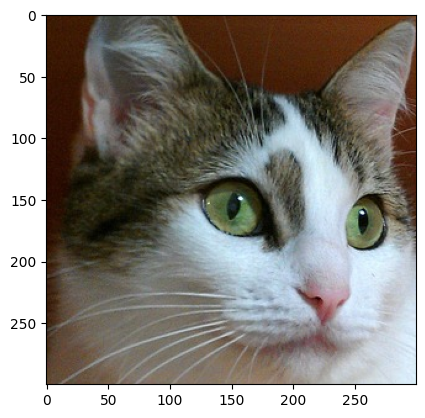

In [3]:
# 裁剪影像
cropped_img = img[50:350, 100:400]  # 注意：矩陣運算，先提供橫列上下界、在提供直排的左右界
opencv_tools.show_img_by_matplotlib(cropped_img)  # 使用 1-E 章節的封裝函式顯示

### 4-2-2 程式範例：影像旋轉

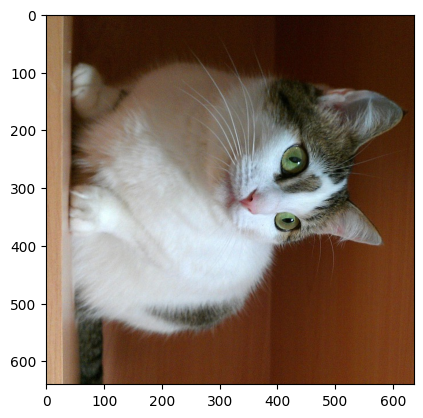

In [4]:
rotated_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
opencv_tools.show_img_by_matplotlib(rotated_img)

### 4-3-2 程式範例：影像縮放

Original size = (637, 640, 3)
After resized = (318, 320, 3)


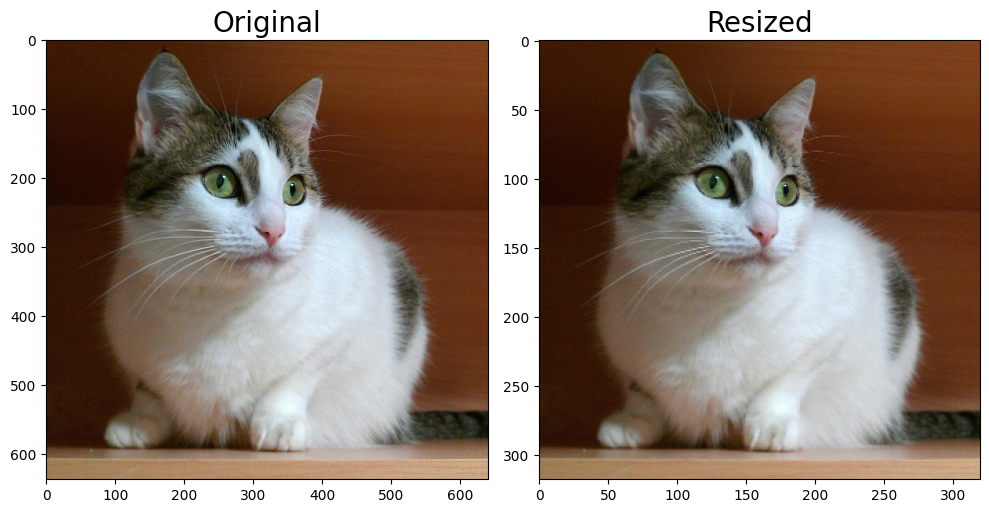

In [5]:
h,w,c = img.shape 

# 使用 cv2.resize 進行影像縮放
resized_img = cv2.resize(img, (w//2, h//2))

# 顯示原圖, 縮放後的影像的大小
print(f"Original size = {img.shape}")
print(f"After resized = {resized_img.shape}")

# 使用 1-E 章節的封裝函式顯示
opencv_tools.show_img_by_matplotlib_1x2(
    "Original", img,
    "Resized", resized_img,
)

Original size = (637, 640, 3)
After resized = (318, 960, 3)


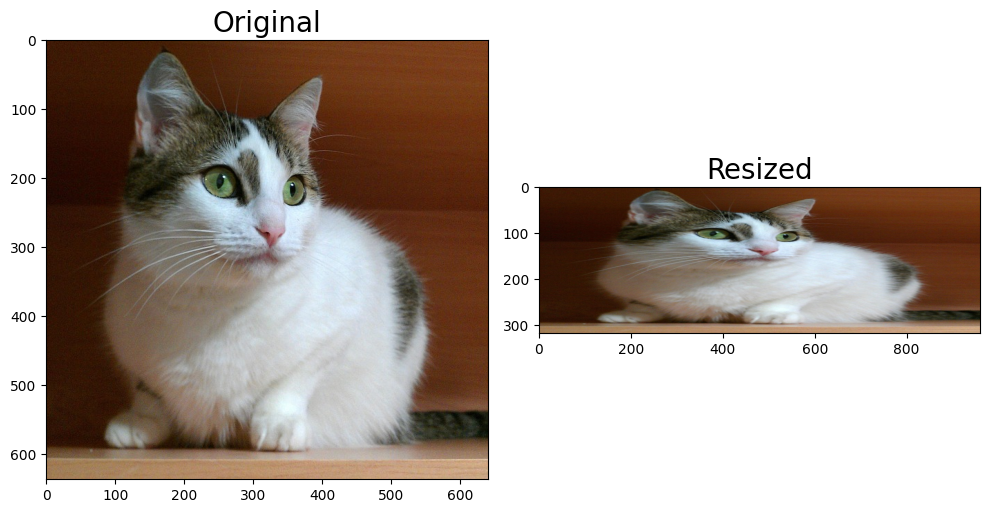

In [6]:
scale_x = 1.5  # 水平方向放大 1.5 倍
scale_y = 0.5  # 垂直方向縮小 0.5倍
resized_img = cv2.resize(img, None, fx=scale_x, fy=scale_y)

# 顯示原圖, 縮放後的影像的大小
print(f"Original size = {img.shape}")
print(f"After resized = {resized_img.shape}")

# 使用 1-E 章節的封裝函式顯示
opencv_tools.show_img_by_matplotlib_1x2(
    "Original", img,
    "Resized", resized_img,
)

### 4-4-2 程式範例：影像翻轉

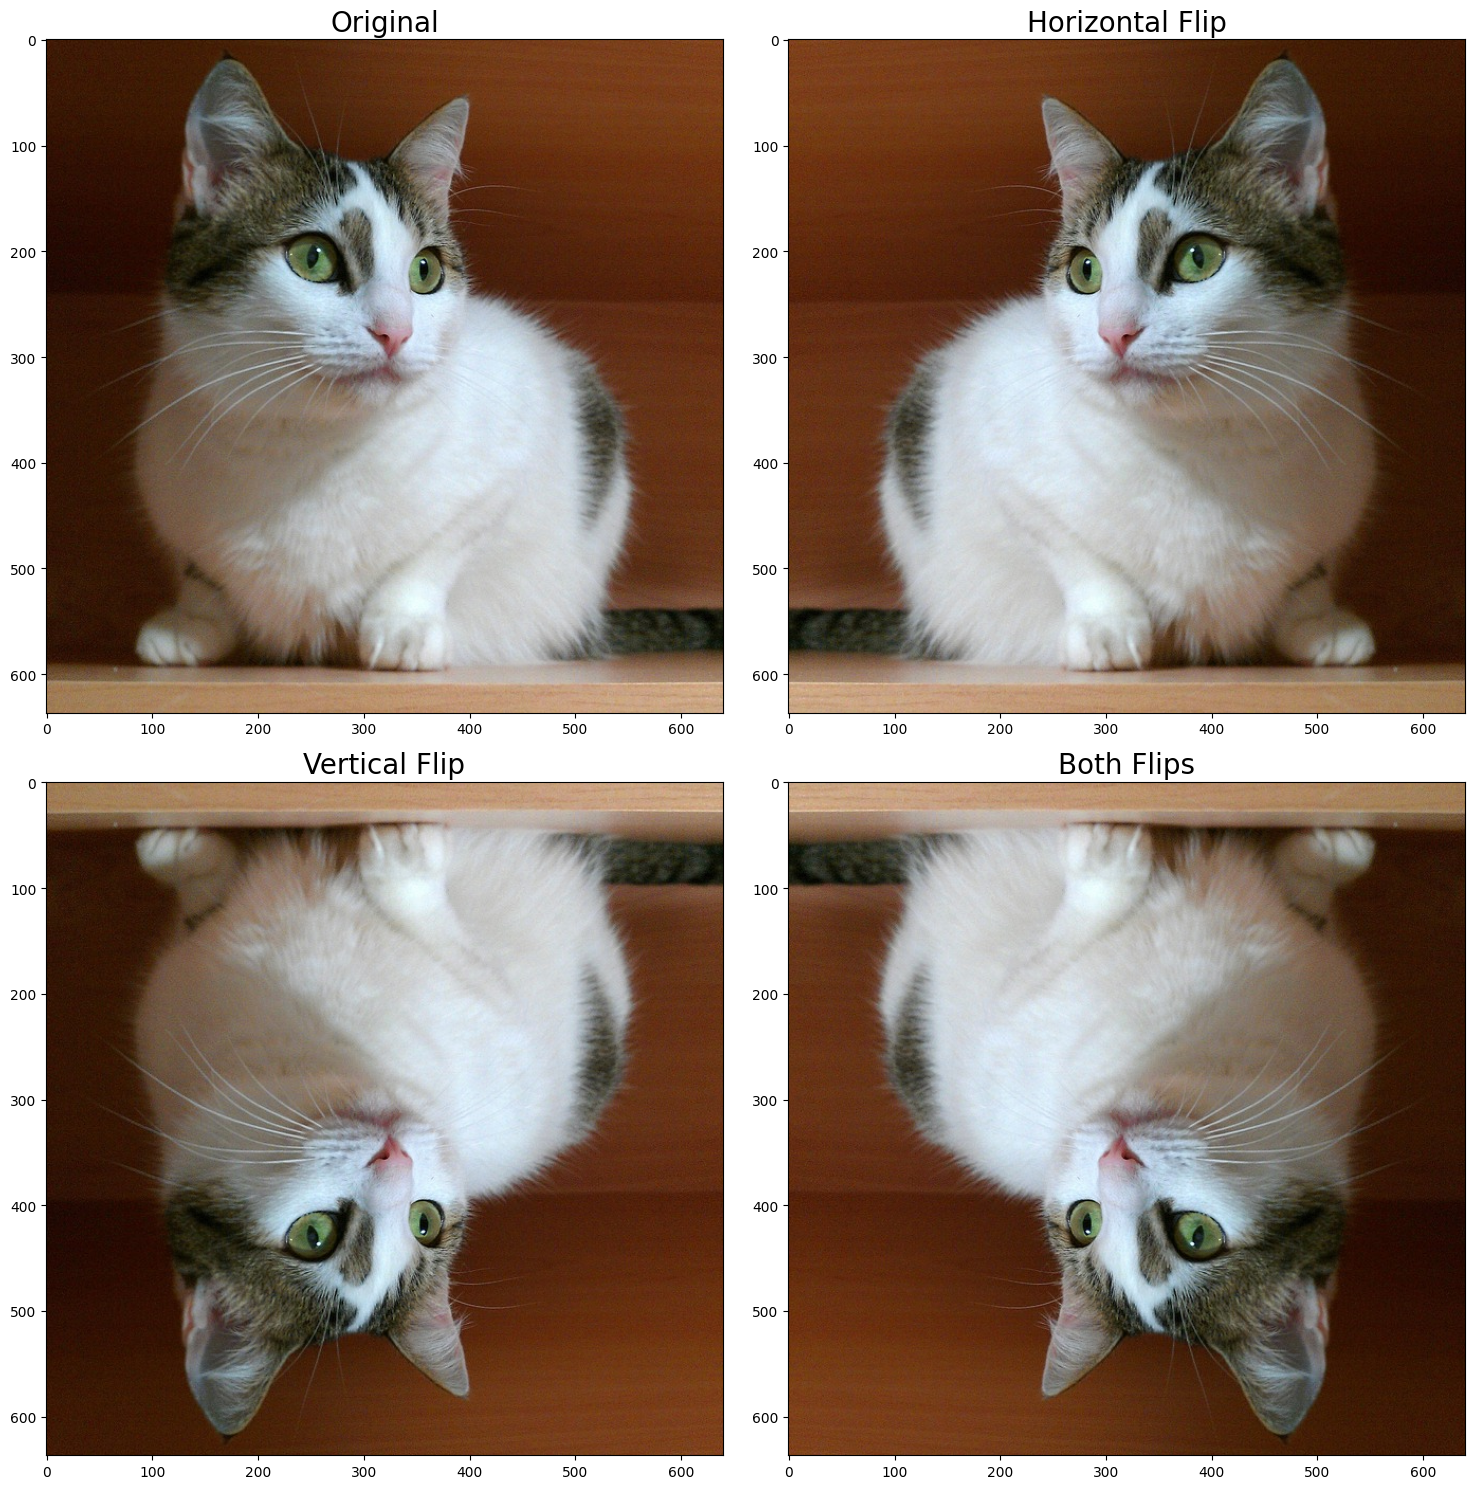

In [7]:
# 讀取影像
img = cv2.imread('sample/cat.jpg') 
horizontal_flip = cv2.flip(img, 1) # 水平翻轉
vertical_flip = cv2.flip(img, 0) # 垂直翻轉
both_flip = cv2.flip(img, -1) # 同時水平與垂直翻轉

# 使用 1-E 章節中封裝的函式，同時顯示 4 組結果
opencv_tools.show_img_by_matplotlib_2x2(
    'Original', img,
    'Horizontal Flip', horizontal_flip,
    'Vertical Flip', vertical_flip,
    'Both Flips', both_flip    
)

### 4-5-4 程式範例：影像平移

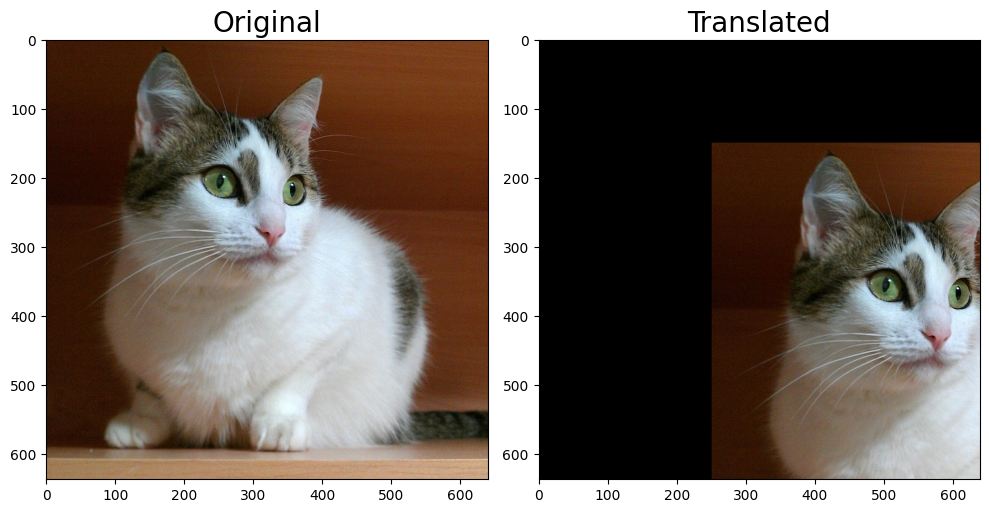

In [8]:
# 讀取影像
img = cv2.imread('sample/cat.jpg')

# 定義平移矩陣，將影像向右移動500個像素，向下移動300個像素
tx, ty = 250, 150
M = np.float32([[1, 0, tx], [0, 1, ty]])

# 進行平移
translated_img = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

# 使用 1-E 章節的封裝函式顯示
opencv_tools.show_img_by_matplotlib_1x2(
    "Original", img,
    "Translated", translated_img,
)

### 4-6-3 程式範例：任意角度的影像旋轉

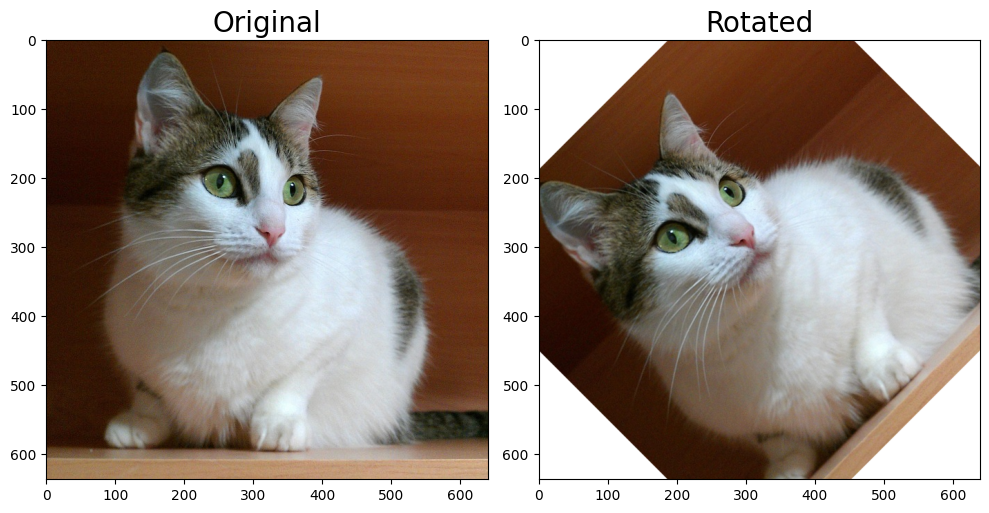

In [9]:
# 計算旋轉中心
h, w, c = img.shape
center = (w // 2, h // 2)
# 取得旋轉矩陣
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
# 應用旋轉矩陣
rotated_img = cv2.warpAffine(img, rotation_matrix, (w, h), borderValue=(255, 255, 255))

# 使用 1-E 章節的封裝函式顯示
opencv_tools.show_img_by_matplotlib_1x2(
    "Original", img,
    "Rotated", rotated_img,
)

### 4-7-3 程式範例：影像傾斜

傾斜後的影像


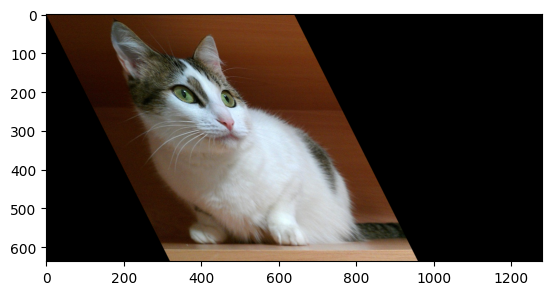

In [10]:
# 讀取影像
img = cv2.imread('sample/cat.jpg')

# 定義原始影像中的三個點
h, w, c = img.shape
pts1 = np.float32([(0, 0), (w, 0), (0, h)]) 

# 定義目標影像中的三個點，製造傾斜效果
pts2 = np.float32([(0, 0), (w, 0), (w//2, h)])

# 計算仿射變換矩陣
M = cv2.getAffineTransform(pts1, pts2)

# 對影像進行仿射投影（傾斜處理）
slanted_img = cv2.warpAffine(img, M, (2*w, h))

print("傾斜後的影像")
opencv_tools.show_img_by_matplotlib(slanted_img)  # 1-E 章節函式

### 4-8-4 程式範例：透視變換

* 步驟 1：取得文件四個邊角座標 

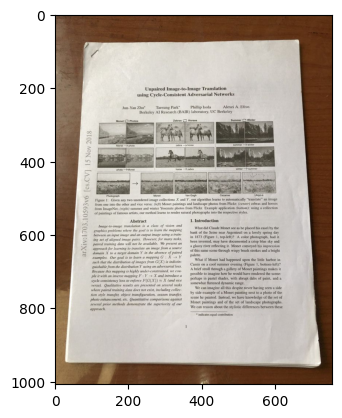

In [11]:
# 讀取影像
img = cv2.imread('sample/paper.jpg')

# 顯示影像，並手動紀錄文件四個邊角座標
opencv_tools.show_img_by_matplotlib(img)

* 步驟 2：設定基準點與目標點 

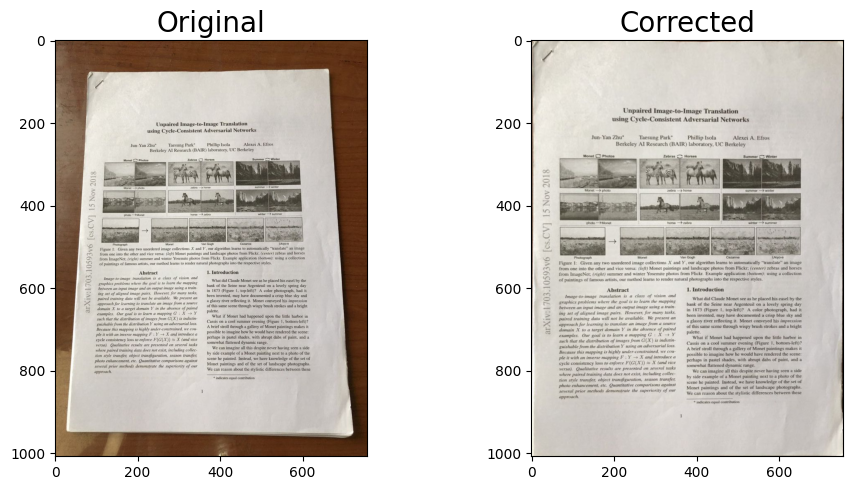

In [12]:
# 定義原始平行四邊形的四個頂點
pts_src = np.array([[78, 80], [662, 68], [721, 955], [28, 945]], dtype=np.float32)

# 查詢原始影像大小，並定義目標長方形的四個頂點
height, width, channels = img.shape
pts_dst = np.array([[0, 0], [width, 0], [width, height], [0, height]], dtype=np.float32)

# 計算透視變換矩陣
M = cv2.getPerspectiveTransform(pts_src, pts_dst)

# 對影像進行透視變換
corrected_img = cv2.warpPerspective(img, M, (width, height))

# 使用 1-E 章節的封裝函式顯示
opencv_tools.show_img_by_matplotlib_1x2(
    "Original", img,
    "Corrected", corrected_img,
)

## 4-E 小專案：自製文件掃描機

In [13]:
# 初始化全域變數
points = []
img_display = None
img_path = 'sample/paper.jpg'

def mouse_click(event, x, y, flags, param):
    """
    滑鼠點擊處理
    """
    global points, img_display
    
    # 監聽滑鼠左鍵點擊 (EVENT_LBUTTONDOWN)
    if event == cv2.EVENT_LBUTTONDOWN:
        # 儲存已經點選的座標
        points.append([x, y])
        print(f"已選擇點 {len(points)}: ({x}, {y})")
        
        # 在顯示用的影像上畫紅圈標記，提供使用者視覺回饋
        cv2.circle(img_display, (x, y), 5, (0, 0, 255), -1)
        # 更新顯示畫面
        cv2.imshow("Select 4 Points (Clockwise)", img_display)

# 主程式
# 讀取影像
img = cv2.imread(img_path)

# 複製一份影像用於顯示，避免汙染原圖
img_display = img.copy()

# 建立視窗並綁定滑鼠功能
window_name = "Select 4 Points (Clockwise)"
cv2.namedWindow(window_name)
cv2.setMouseCallback(window_name, mouse_click)

print("請依照順時針順序點擊四個角落：左上 -> 右上 -> 右下 -> 左下")
cv2.imshow(window_name, img_display)

# 等待直到收集滿 4 個點
while len(points) < 4:
    # 按 'q' 可以隨時強制退出
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
        
cv2.destroyAllWindows()

# 只有當點選了 4 個點才執行變換
if len(points) == 4:
    # 1. 定義原始四個頂點 (來自滑鼠點擊)
    pts_src = np.array(points, dtype=np.float32)
    
    # 2. 查詢原始影像大小，做為目標長方形的四個頂點 (維持原圖大小)
    height, width = img.shape[:2]
    pts_dst = np.array([[0, 0], [width, 0], [width, height], [0, height]], dtype=np.float32)
    
    # 3. 計算透視變換矩陣
    M = cv2.getPerspectiveTransform(pts_src, pts_dst)
    
    # 4. 對影像進行透視變換
    corrected_img = cv2.warpPerspective(img, M, (width, height))
    
    # 4. 儲存文件
    # 分離檔名與副檔名 (例如: 'folder/photo' 和 '.jpg')
    root, ext = os.path.splitext(img_path)
    # 組合新檔名
    output_filename = f"{root}_corrected{ext}"
    
    cv2.imwrite(output_filename, corrected_img)
    print(f"【成功】已儲存至：{output_filename}")
    
else:
    print("未選滿 4 個點，程式結束。")

請依照順時針順序點擊四個角落：左上 -> 右上 -> 右下 -> 左下
已選擇點 1: (83, 77)
已選擇點 2: (664, 68)
已選擇點 3: (719, 955)
已選擇點 4: (30, 944)
【成功】已儲存至：sample/paper_corrected.jpg
